### Bài toán 1: Thuật toán OMP

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

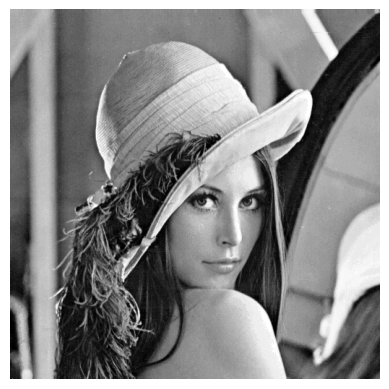

In [ ]:
image = cv2.imread('/content/lenna.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.axis('off')

In [ ]:
def blockDivide(img, block_size):
  if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise ValueError("Ảnh đầu vào phải là ma trận 2D (Gray-scale).")
  height, width = img.shape
  if height % block_size != 0 or width % block_size != 0:
        raise ValueError("Kích thước khối phải chia hết cho kích thước ảnh.")
  num_block_y = height // block_size
  num_block_x = width // block_size
  blocks = []
  for i in range(num_block_y):
    for j in range(num_block_x):
      block = img[i * block_size:(i + 1) * block_size, j * block_size:(j + 1) * block_size]
      block_vector = block.flatten()
      blocks.append(block_vector)
  return blocks

In [ ]:
def DCT_1D(N):
  dct_mat = np.zeros((N, N))
  for i in range(N):
    for j in range(N):
      if i == 0:
        dct_mat[i, j] = 1 / np.sqrt(N)
      else:
        dct_mat[i, j] = np.sqrt(2 / N) * np.cos(np.pi * (2 * j + 1) * i / (2 * N))
  return dct_mat

In [ ]:
def DCT2_Basis(B):
  dct1 = DCT_1D(B)
  dct_2d = np.kron(dct1, dct1)
  return dct_2d

In [ ]:
def OMP(D, x, sparsity):
  M, K = D.shape
  residual = x.copy()
  atoms = []
  alpha = np.zeros(K)
  for i in range(1, sparsity):
    correlations = np.abs(np.dot(D.T, residual))
    atom_index = np.argmax(correlations)
    atoms.append(atom_index)
    D_used = D[:, atoms]
    alpha_used = np.linalg.lstsq(D_used, x, rcond=None)[0]
    alpha[atoms] = alpha_used
    residual = x - np.dot(D_used, alpha_used)
    if np.linalg.norm(residual) < 1e-10:
      break
  return alpha

In [ ]:
def reconstruct_image(blocks, block_size, height, width):
    num_blocks_y = height // block_size
    num_blocks_x = width // block_size
    reconstructed_img = np.zeros((height, width))
    block_idx = 0
    for i in range(num_blocks_y):
        for j in range(num_blocks_x):
            block_vector = blocks[block_idx]
            block = block_vector.reshape(block_size, block_size)
            reconstructed_img[i * block_size:(i + 1) * block_size, j * block_size:(j + 1) * block_size] = block
            block_idx += 1
    return reconstructed_img

In [ ]:
def reconstruct_image_with_omp(img, block_size, D, sparsity):
    # Chia ảnh thành các block
    blocks = blockDivide(img, block_size)

    # Tái tạo từng block bằng OMP
    reconstructed_blocks = []
    total_atoms_used = 0
    for block in blocks:
        # Áp dụng OMP để tìm alpha
        alpha = OMP(D, block, sparsity)
        # Tái tạo block: D @ alpha
        reconstructed_block = np.dot(D, alpha)
        reconstructed_blocks.append(reconstructed_block)

        # Tính số lượng atoms được sử dụng (số phần tử khác 0 trong alpha)
        atoms_used = np.count_nonzero(alpha)
        total_atoms_used += atoms_used

    # Ghép các block lại thành ảnh
    height, width = img.shape
    reconstructed_img = reconstruct_image(reconstructed_blocks, block_size, height, width)

    # Tính số lượng atoms trung bình
    avg_atoms_used = total_atoms_used / len(blocks)

    return reconstructed_img, avg_atoms_used

In [ ]:
def evaluate_image(original_img, reconstructed_img, avg_atoms_used):
    # Tính PSNR
    psnr_value = psnr(original_img, reconstructed_img, data_range=original_img.max() - original_img.min())

    # Tính SSIM
    ssim_value = ssim(original_img, reconstructed_img, data_range=original_img.max() - original_img.min())

    # Tạo từ điển kết quả
    metrics = {
        "Sparsity": avg_atoms_used,
        "PSNR": psnr_value,
        "SSIM": ssim_value
    }

    return metrics

Sparsity: 0, Metrics: {'Sparsity': 0.0, 'PSNR': np.float64(3.3432062349000864), 'SSIM': np.float64(0.00017796467846436834)}


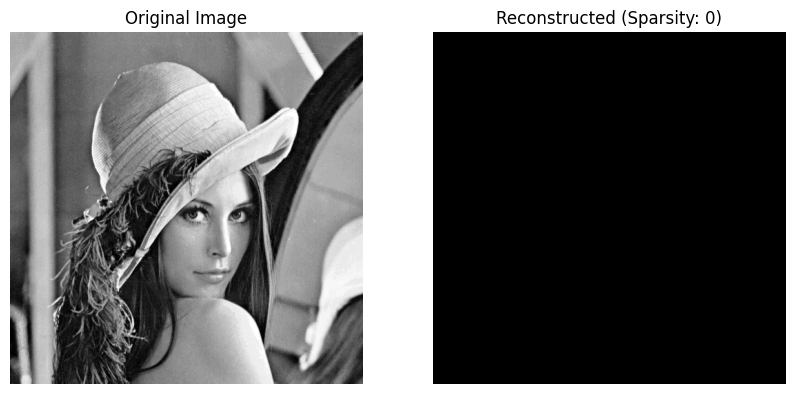

Sparsity: 10, Metrics: {'Sparsity': 9.0, 'PSNR': np.float64(19.19041009837835), 'SSIM': np.float64(0.3629986566017666)}


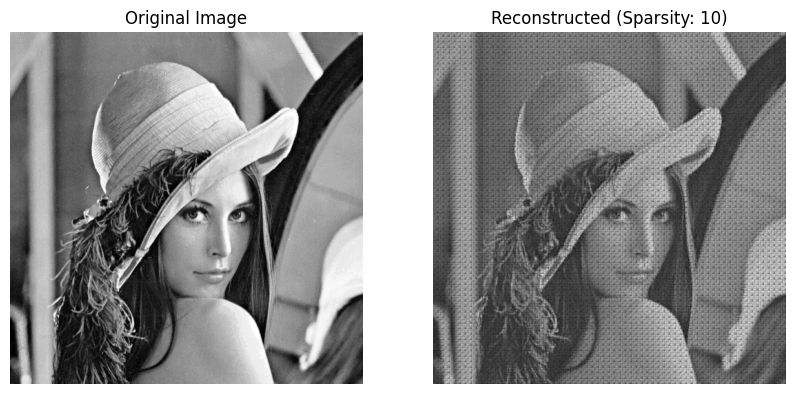

Sparsity: 20, Metrics: {'Sparsity': 19.0, 'PSNR': np.float64(26.742362625136895), 'SSIM': np.float64(0.6450768524034262)}


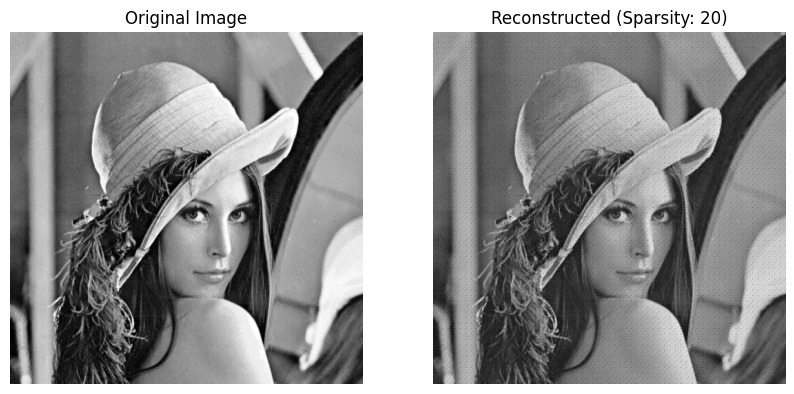

Sparsity: 30, Metrics: {'Sparsity': 29.0, 'PSNR': np.float64(32.53510044779639), 'SSIM': np.float64(0.8461315375063757)}


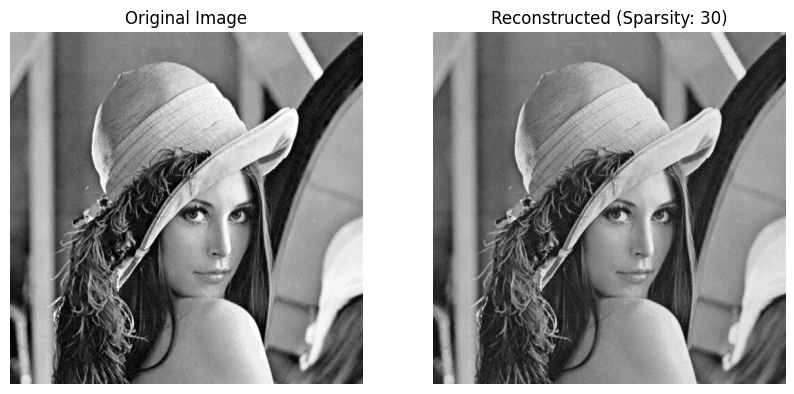

Sparsity: 40, Metrics: {'Sparsity': 39.0, 'PSNR': np.float64(38.38477372528962), 'SSIM': np.float64(0.9538001514802014)}


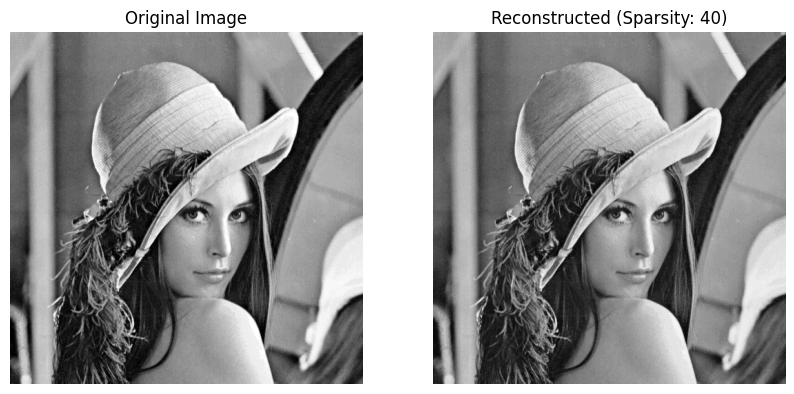

Sparsity: 50, Metrics: {'Sparsity': 49.0, 'PSNR': np.float64(45.56553856473072), 'SSIM': np.float64(0.9910885098073642)}


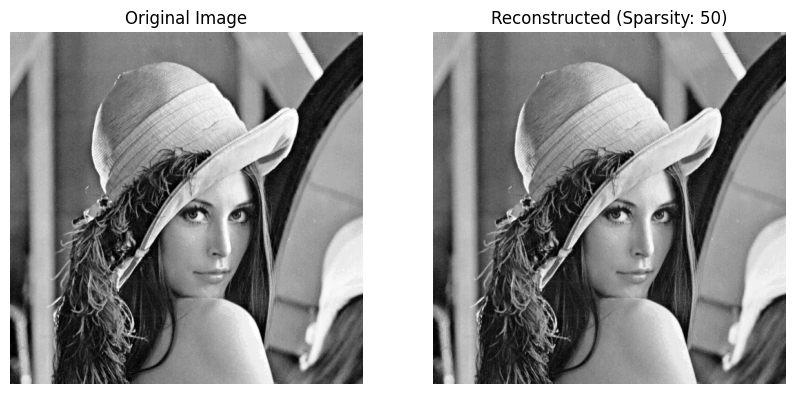

In [ ]:
block_size = 8

# Create DCT Basis
D = DCT2_Basis(block_size)

# Sparsity levels to test
sparsity_levels = range(0, 60, 10)

# Iterate through sparsity levels
for sparsity in sparsity_levels:
    # Reconstruct image with current sparsity
    reconstructed_img, avg_atoms_used = reconstruct_image_with_omp(image, block_size, D, sparsity)

    # Evaluate the reconstruction
    metrics = evaluate_image(image, reconstructed_img, avg_atoms_used)
    print(f"Sparsity: {sparsity}, Metrics: {metrics}")

    # Display original and reconstructed images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns for images

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(reconstructed_img, cmap='gray')
    axes[1].set_title(f'Reconstructed (Sparsity: {sparsity})')
    axes[1].axis('off')

    plt.show()

### Bài toán 2: Nén ảnh chuẩn JPEG

In [ ]:
import os
from scipy.fftpack import dct, idct
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

In [ ]:
def blockDivide(img, block_size):
  h,w = img.shape
  pad_h = (block_size - h % block_size) % block_size
  pad_w = (block_size - w % block_size) % block_size
  img_padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
  blocks = []
  for i in range(0, img_padded.shape[0], block_size):
    for j in range(0, img_padded.shape[1], block_size):
      block = img_padded[i:i+block_size, j:j+block_size]
      blocks.append(block)
  return blocks, img_padded.shape


In [ ]:
def dct2(block):
  return dct(dct(block.T, norm='ortho').T, norm='ortho')

In [ ]:
def idct2(block):
  return idct(idct(block.T, norm='ortho').T, norm='ortho')

In [ ]:
Q = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
             [12, 12, 14, 19, 26, 58, 60, 55],
             [14, 13, 16, 24, 40, 57, 69, 56],
             [14, 17, 22, 29, 51, 87, 80, 62],
             [18, 22, 37, 56, 68, 109, 103, 77],
             [24, 35, 55, 64, 81, 104, 113, 92],
             [49, 64, 78, 87, 103, 121, 120, 101],
             [72, 92, 95, 98, 112, 100, 103, 99]], dtype=np.float32)

In [ ]:
def jpeg_compress(img, Q):
  blocks, padded_shape = blockDivide(img, block_size=8)
  compressed_blocks = []
  for block in blocks:
    block = block.astype(np.float32) - 128
    dct_block = dct2(block)
    quant_block = np.round(dct_block / Q)
    compressed_blocks.append(quant_block)
  return compressed_blocks, padded_shape

In [ ]:
def jpeg_decompress(compressed_blocks, padded_shape, Q, original_shape):
    h_pad, w_pad = padded_shape
    block_size = 8
    rec_img = np.zeros((h_pad, w_pad), dtype=np.float32)
    idx = 0
    for i in range(0, h_pad, block_size):
        for j in range(0, w_pad, block_size):
            quant_block = compressed_blocks[idx]
            dequant_block = quant_block * Q
            idct_block = idct2(dequant_block) + 128
            rec_img[i:i+block_size, j:j+block_size] = idct_block
            idx += 1
    h_orig, w_orig = original_shape
    return np.clip(rec_img[:h_orig, :w_orig], 0, 255).astype(np.uint8)

Dung lượng của ảnh 1: 150401 bytes
Dung lượng của ảnh 2: 152861 bytes
PSNR: 34.85 dB
SSIM: 0.9033


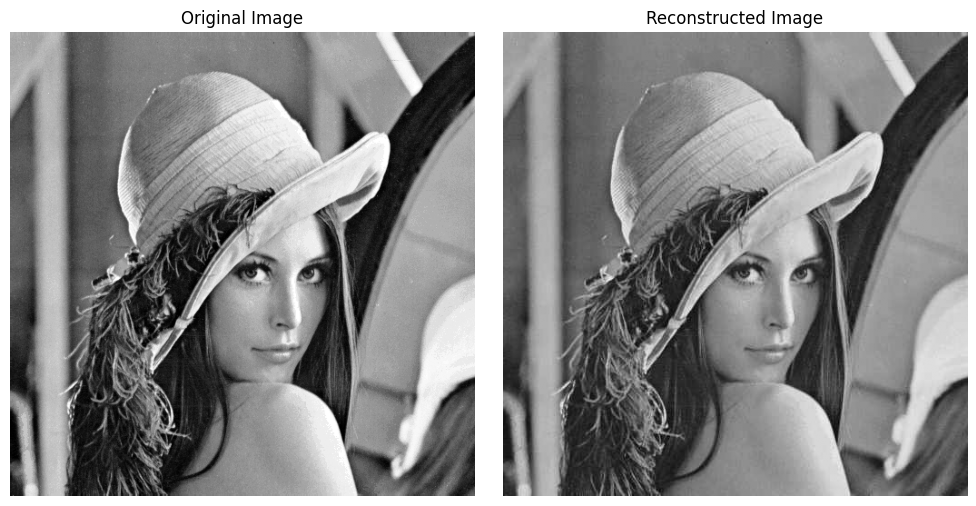

In [ ]:
# Store the original shape for later use
original_shape = image.shape

# Compress the image
compressed_blocks, padded_shape = jpeg_compress(image, Q)

# Decompress the image
reconstructed_img = jpeg_decompress(compressed_blocks, padded_shape, Q, original_shape)

# Save the reconstructed image (optional)
cv2.imwrite('reconstructed_image.png', reconstructed_img)
cv2.imread('/content/reconstructed_image.png')

image_path1 = "/content/lenna.png"
image_path2 = "/content/reconstructed_image.png"

image_size1 = os.path.getsize(image_path1)
image_size2 = os.path.getsize(image_path2)

print(f"Dung lượng của ảnh 1: {image_size1} bytes")
print(f"Dung lượng của ảnh 2: {image_size2} bytes")
# Compute PSNR and SSIM
psnr_value = psnr(image, reconstructed_img, data_range=255)
ssim_value = ssim(image, reconstructed_img, data_range=255)

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.4f}")
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

# Show the plot
plt.tight_layout()
plt.show()